# Evaluate similarity suggestions

In [1]:
%load_ext autoreload

In [2]:
import gc
import os
import pickle
import warnings
from os.path import join
from IPython.display import display, Markdown, display_html

import scanpy as sc
import pandas as pdx 
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt

In [3]:
%autoreload
from datasim.dataset_ot import DatasetMapping

## Load and preprocess data

In [4]:
DATA_PATH = "/vol/data/dataset-similarity/preprocessed"
CACHE_DIR = "/vol/data/dataset-similarity/cache"
FIG_DIR = "/vol/data/dataset-similarity/figures"


QUERY_DATASET = "7d7cabfd-1d1f-40af-96b7-26a0825a306d"
REF_DATASET = "ced320a1-29f3-47c1-a735-513c7084d508"
N_TOP_GENES = 3000

In [5]:
cache_file = join(
    CACHE_DIR, 
    "+".join([QUERY_DATASET, REF_DATASET, f"{N_TOP_GENES}HVGs"]) + ".pickle"
)
if os.path.isfile(cache_file):
    print("Using cached files...")
    with open(cache_file, "rb") as f:
        adata_query, adata_ref = pickle.load(f)
else:
    # load and preprocess data
    adata_query, adata_ref = DatasetMapping.preprocess_adatas(
        sc.read_h5ad(join(DATA_PATH, f"{QUERY_DATASET}.h5ad")),
        sc.read_h5ad(join(DATA_PATH, f"{REF_DATASET}.h5ad")),
        n_top_genes=N_TOP_GENES
    )
    with open(cache_file, "wb") as f:
        pickle.dump((adata_query, adata_ref), f)

adata_query.obs["cell_type_author"] = adata_query.obs["ct2"]
gc.collect();

Using cached files...


In [6]:
# normalize data for DE tests
sc.pp.normalize_total(adata_query, target_sum=1e4)
sc.pp.normalize_total(adata_ref, target_sum=1e4)
sc.pp.log1p(adata_query)
sc.pp.log1p(adata_ref)

In [7]:
# Use human readable gene names for evaluation
adata_query.var.set_index("feature_name", inplace=True)
adata_ref.var.set_index("feature_name", inplace=True)

In [8]:
adata_query

AnnData object with n_obs × n_vars = 600929 × 3000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'ct1', 'ct2', 'ct3', 'cell_type_author'
    uns: 'log1p'

In [9]:
adata_ref

AnnData object with n_obs × n_vars = 1058909 × 3000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'author_cell_type', 'cell_type_author'
    uns: 'log1p'

In [10]:
MODEL_VERSION = "_n_genes_de_gene_overlap=10+tau=1.00+n_top_genes=3000"

cluster_mapping = pd.read_parquet(f"/vol/data/dataset-similarity/model-output/cluster_mapping{MODEL_VERSION}.parquet")
cluster_distance = pd.read_parquet(f"/vol/data/dataset-similarity/model-output/cluster_distance{MODEL_VERSION}.parquet")

In [11]:
top_n_labels = DatasetMapping.select_most_similar_clusters(
    cluster_mapping, 
    cluster_distance, 
    threshold_mass=0.25,
    threshold_distance=1.1, 
    n_top=None
)
top_n_labels

{'B_Mem': ['IGHMhi_memory_B'],
 'B_Mem_Prolif': ['IGHMlo_memory_B'],
 'B_Naive': ['naive_B'],
 'B_Preplasma': ['atypical_B'],
 'NKT': ['CD4+_T_cyt', 'NK'],
 'NK_CD16+': ['CD16+_NK'],
 'NK_CD56++': ['CD56+_NK'],
 'NK_Prolif': [],
 'PB': ['Plasma_B'],
 'PB_Prolif': [],
 'Progen_CLP': [],
 'Progen_CMP': [],
 'Progen_MEP': [],
 'Progen_MPP': [],
 'T4_Mem': ['CD4+_T_cm'],
 'T4_Mem_Prolif': [],
 'T4_Naive': ['CD4+_T_naive'],
 'T4_Treg': ['Treg'],
 'T8_MAIT': ['MAIT'],
 'T8_Mem': ['CD8+_T_GZMB+'],
 'T8_Mem_Prolif': ['CD8+_T_GZMK+'],
 'T8_Naive': ['CD8+_T_naive'],
 'T_NK_Prolif': [],
 'Tgd_1': ['CD4+_T_cyt'],
 'Tgd_2': ['gdT'],
 'cDC_1': ['cDC1'],
 'cDC_2': ['cDC2', 'cDC'],
 'cM': ['CD14+_Monocyte'],
 'ncM': ['CD16+_Monocyte'],
 'pDC': ['pDC']}

## Visualize overlap of DE genes

In [12]:
%autoreload
from datasim.label_distance import de_gene_overlap_label_distance

In [20]:
# ignore warnings here as scanpy.tl.rank_genes_groups throws a lot of warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    overlap_top10 = de_gene_overlap_label_distance(
        adata_query, adata_ref, "cell_type_author",
        n_genes=10,
    )
    overlap_top10 = (-overlap_top10.T + 1.) * 100.
    overlap_top10 = overlap_top10.sort_index().loc[:, sorted(overlap_top10.columns)]
    overlap_top20 = de_gene_overlap_label_distance(
        adata_query, adata_ref, "cell_type_author",
        n_genes=20,
    )
    overlap_top20 = (-overlap_top20.T + 1.) * 100.
    overlap_top20 = overlap_top20.sort_index().loc[:, sorted(overlap_top20.columns)]


In [62]:
import plotly.express as px


def plot_overlap_heatmap(overlap, top_n_labels, title):
    ordering = overlap.columns.tolist()
    for i, s in enumerate(top_n_labels.values()):
        if s:
            pos_best = ordering.index(s[0])
            ordering[i], ordering[pos_best] = ordering[pos_best], ordering[i]

    overlap = overlap.loc[:, ordering]
    fig = px.imshow(overlap, text_auto=".0f", color_continuous_scale="RdYlGn", zmin=0., zmax=100.)
    fig.update_layout(autosize=False, width=900, height=800, title=title)
    for k, v in top_n_labels.items():
        if v:
            row = overlap.index.tolist().index(k)
            col = overlap.columns.tolist().index(v[0])
            if overlap.iloc[row, col] >= overlap.iloc[row, :].max():
                color = "blue"
            else:
                color = "cyan"
            fig.add_shape(
                type="rect",
                x0=col - 0.5, y0=row - 0.5,
                x1=col + 0.5, y1=row + 0.5,
                line=dict(color=color, width=2)
            )

    return fig


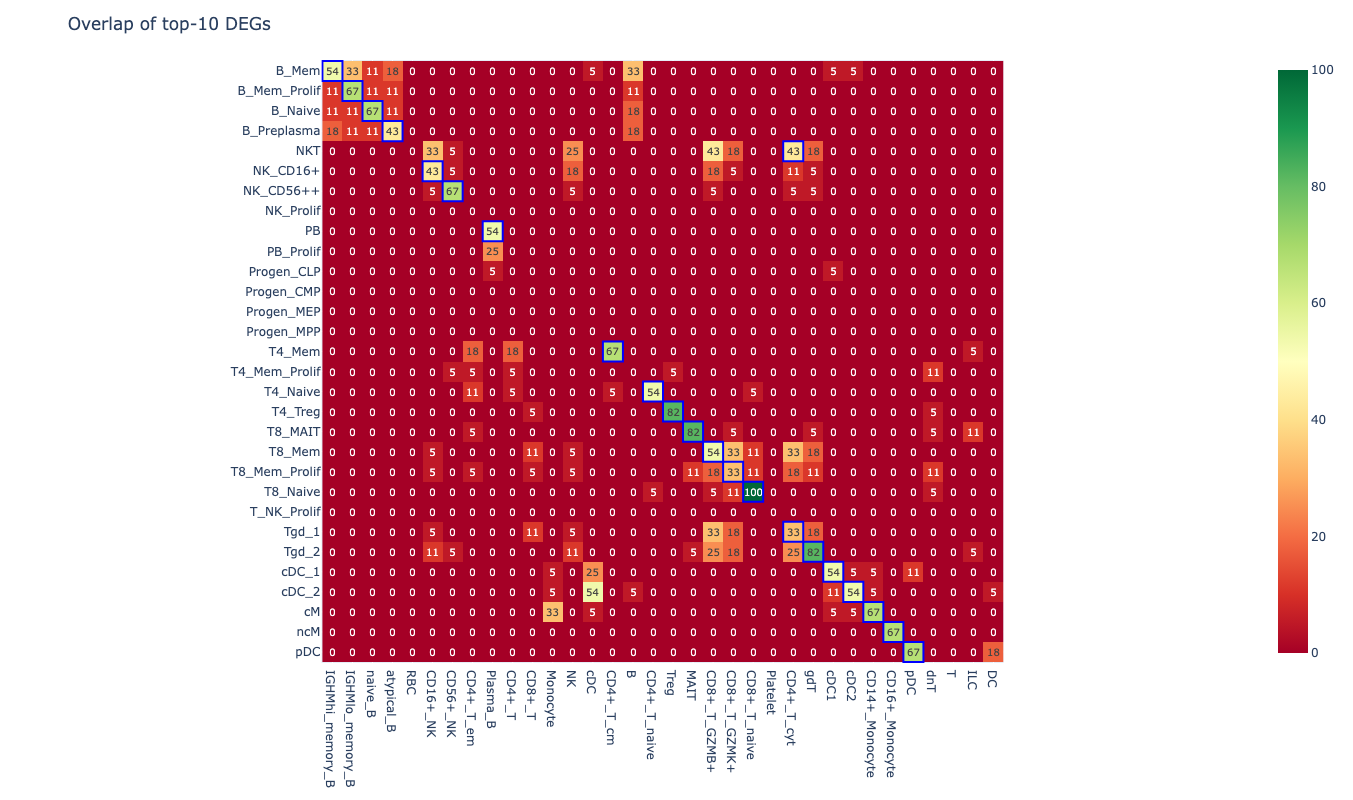

In [63]:
plot_overlap_heatmap(overlap_top10, top_n_labels, "Overlap of top-10 DEGs")

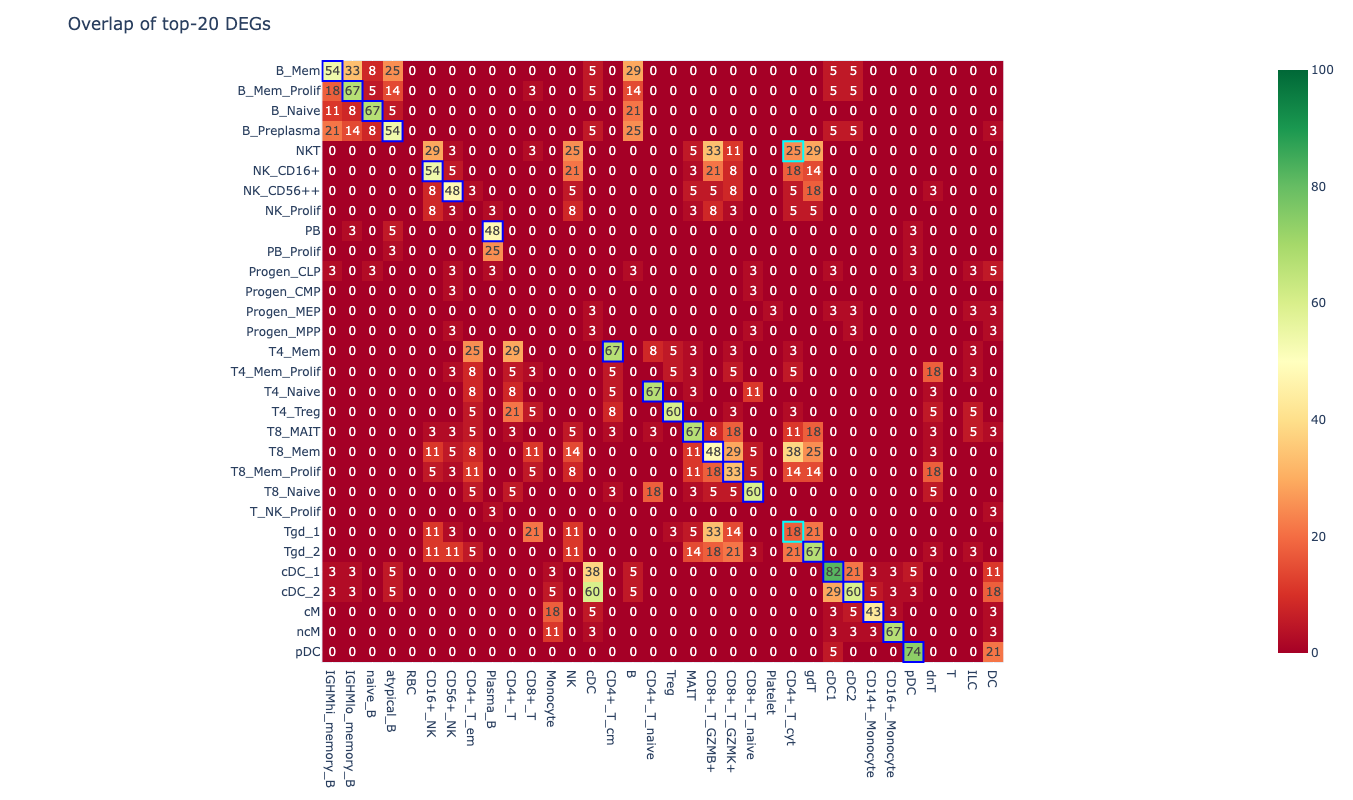

In [64]:
plot_overlap_heatmap(overlap_top20, top_n_labels, "Overlap of top-20 DEGs")